,data_num,ops_num,load_hashmap_time,load_hj_time,ops_hashmap_time,ops_hj_time
0,100,100,22.403333,451.460000,168.500000,604.696667
1,100,500,16.610000,309.193333,709.293333,2670.000000
2,100,1000,16.136667,243.503333,1426.666667,5693.333333
3,500,100,81.530000,346.973333,143.346667,670.986667
4,500,500,84.780000,381.643333,827.306667,3486.666667
5,500,1000,77.643333,334.530000,1403.333333,7153.333333
6,1000,100,149.696667,574.470000,158.873333,921.026667
7,1000,500,157.613333,536.166667,705.830000,4583.333333
8,1000,1000,150.610000,560.250000,1480.000000,9370.000000


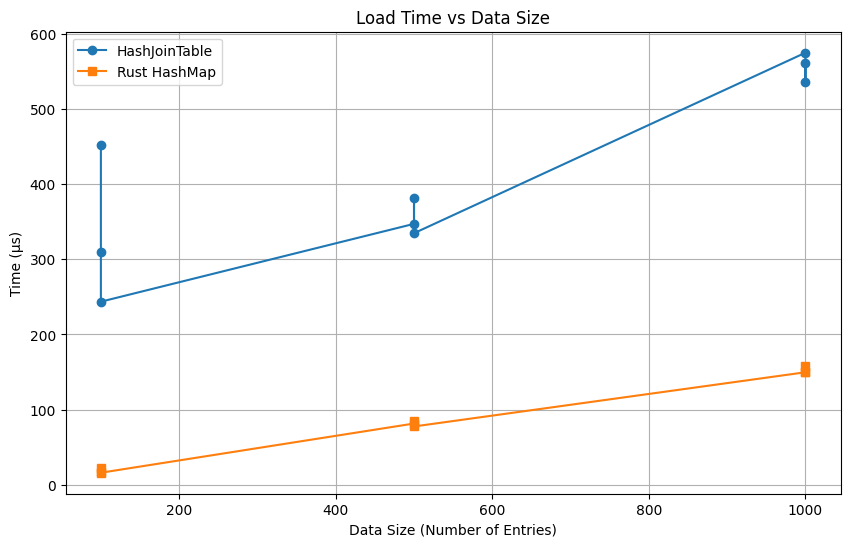

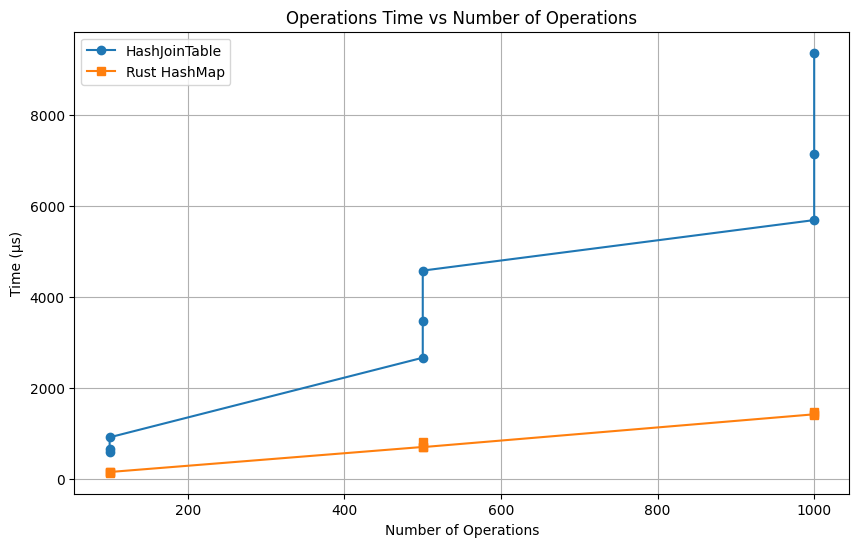

In [ ]:
# Hash Join Benchmark Notebook

# 1. Import Necessary Libraries
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display, clear_output

# 2. Define Paths
# Define the current directory as the script directory
SCRIPT_DIR = os.path.abspath('.')
print(f"Script directory: {SCRIPT_DIR}")

# If your Rust project is in the same directory, PROJECT_ROOT is the same as SCRIPT_DIR
PROJECT_ROOT = SCRIPT_DIR
print(f"Project root directory: {PROJECT_ROOT}")

# 3. Define Functions

# 3.1 Function to Generate Data
def generate_data(data_params):
    """
    Run gen_data.py with specified parameters.
    """
    gen_data_script = os.path.join(SCRIPT_DIR, 'gen_data.py')
    cmd = ['python3', gen_data_script] + data_params.split()
    print(f"Running gen_data.py with parameters: {data_params}")
    subprocess.run(cmd, check=True)

# 3.2 Function to Generate Transactions
def generate_transactions(txs_params):
    """
    Run gen_txs.py with specified parameters.
    """
    gen_txs_script = os.path.join(SCRIPT_DIR, 'gen_txs.py')
    cmd = ['python3', gen_txs_script] + txs_params.split()
    print(f"Running gen_txs.py with parameters: {txs_params}")
    subprocess.run(cmd, check=True)

# 3.3 Function to Generate Data After Transactions
def generate_data_after_txs():
    """
    Run gen_data_after_txs.py to generate recent and history data after transactions and operations.
    """
    gen_data_after_txs_script = os.path.join(SCRIPT_DIR, 'gen_data_after_txs.py')
    cmd = [
        'python3', gen_data_after_txs_script,
        '--data_file', os.path.join(SCRIPT_DIR, 'data.csv'),
        '--txs_file', os.path.join(SCRIPT_DIR, 'txs.csv'),
        '--ops_file', os.path.join(SCRIPT_DIR, 'ops.csv'),
        '--recent_data_after_txs_file', os.path.join(SCRIPT_DIR, 'recent_data_after_txs.csv'),
        '--history_data_after_txs_file', os.path.join(SCRIPT_DIR, 'history_data_after_txs.csv'),
        '--recent_data_after_ops_file', os.path.join(SCRIPT_DIR, 'recent_data_after_ops.csv'),
        '--history_data_after_ops_file', os.path.join(SCRIPT_DIR, 'history_data_after_ops.csv'),
    ]
    print("Running gen_data_after_txs.py...")
    subprocess.run(cmd, check=True)

# 3.4 Function to Run Benchmark and Capture Output
def run_benchmark():
    """
    Build and run the benchmark, capturing the output.
    """
    # Change to the project root directory
    os.chdir(PROJECT_ROOT)
    
    # Build the Rust project
    print("Building the Rust project...")
    subprocess.run(['cargo', 'build', '--release'], check=True)
    
    # Define paths to data files
    data_csv = os.path.join(SCRIPT_DIR, 'data.csv')
    ops_csv = os.path.join(SCRIPT_DIR, 'ops.csv')
    recent_data_csv = os.path.join(SCRIPT_DIR, 'recent_data_after_ops.csv')
    history_data_csv = os.path.join(SCRIPT_DIR, 'history_data_after_ops.csv')
    
    # Run the benchmark and capture the output
    print("Running the Rust benchmark...")
    cmd = [
        'cargo', 'run', '--release', '--bin', 'hash_join_bench', '--',
        data_csv, ops_csv, recent_data_csv, history_data_csv
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    output = result.stdout
    print(output)
    return output

# 3.5 Function to Parse Benchmark Output
def parse_benchmark_output(output):
    """
    Parse the benchmark output and extract performance metrics.
    """
    metrics = {}
    # Use regular expressions to extract timing information
    load_hashmap_match = re.search(r"Loaded (\d+) entries into Rust HashMap in ([\d.]+)(\w+)", output)
    load_hj_match = re.search(r"Loaded (\d+) entries into HashJoinTable in ([\d.]+)(\w+)", output)
    ops_hashmap_match = re.search(r"Rust HashMap: Executed (\d+) operations in ([\d.]+)(\w+)", output)
    ops_hj_match = re.search(r"HashJoinTable: Executed (\d+) operations in ([\d.]+)(\w+)", output)
    
    if load_hashmap_match:
        metrics['data_num'] = int(load_hashmap_match.group(1))
        metrics['load_hashmap_time'] = convert_to_microseconds(float(load_hashmap_match.group(2)), load_hashmap_match.group(3))
    if load_hj_match:
        metrics['load_hj_time'] = convert_to_microseconds(float(load_hj_match.group(2)), load_hj_match.group(3))
    if ops_hashmap_match:
        metrics['ops_num'] = int(ops_hashmap_match.group(1))
        metrics['ops_hashmap_time'] = convert_to_microseconds(float(ops_hashmap_match.group(2)), ops_hashmap_match.group(3))
    if ops_hj_match:
        metrics['ops_hj_time'] = convert_to_microseconds(float(ops_hj_match.group(2)), ops_hj_match.group(3))
    
    return metrics

def convert_to_microseconds(value, unit):
    """
    Convert time value to microseconds based on the unit.
    """
    unit = unit.strip()
    if unit == 's':
        return value * 1e6
    elif unit == 'ms':
        return value * 1e3
    elif unit == 'µs' or unit == 'us':
        return value
    elif unit == 'ns':
        return value / 1e3
    else:
        return value  # Default to microseconds if unit is unrecognized

# 4. Define Parameter Ranges and Run Benchmarks

import itertools

results = []

# Define ranges for data_num and ops_num
# data_nums = [1000, 5000, 10000]
# ops_nums = [1000, 5000, 10000]
data_nums = [100]
ops_nums = [100, 500, 1000]

# Loop over combinations of data_num and ops_num
for data_num, ops_num in itertools.product(data_nums, ops_nums):
    # Update parameters for data generation and transactions
    data_params = f"-n {data_num} -k 8 -p 8 -vmin 32 -vmax 64 -s 5"
    txs_params = f"-n {ops_num} -minc 8 -maxc 12 -ro 0.0 -i 0.1 -u 0.3 -d 0.1 -g 0.5"
    
    print(f"\nRunning benchmark with data_num={data_num}, ops_num={ops_num}")
    
    # Generate data
    generate_data(data_params)
    
    # Generate transactions
    generate_transactions(txs_params)
    
    # Generate data after transactions
    generate_data_after_txs()
    
    # Run the benchmark multiple times and collect results
    num_runs = 10  # Adjust the number of runs for averaging
    metrics_list = []
    for run in range(num_runs):
        print(f"Run {run+1}/{num_runs}")
        output = run_benchmark()
        metrics = parse_benchmark_output(output)
        metrics_list.append(metrics)
    
    # Compute averages
    avg_metrics = {
        'data_num': data_num,
        'ops_num': ops_num,
        'load_hashmap_time': np.mean([m['load_hashmap_time'] for m in metrics_list]),
        'load_hj_time': np.mean([m['load_hj_time'] for m in metrics_list]),
        'ops_hashmap_time': np.mean([m['ops_hashmap_time'] for m in metrics_list]),
        'ops_hj_time': np.mean([m['ops_hj_time'] for m in metrics_list]),
    }
    results.append(avg_metrics)
    
    # Clear the output to keep the notebook clean
    clear_output(wait=True)

# 5. Create a DataFrame from Results
df = pd.DataFrame(results)

# 6. Display the DataFrame
display(df)

# 7. Plot the Results

# 7.1 Function to Plot Metrics
def plot_metric(df, x_param, metric_hj, metric_hashmap, title, xlabel):
    plt.figure(figsize=(10, 6))
    
    plt.plot(df[x_param], df[metric_hj], marker='o', label='HashJoinTable')
    plt.plot(df[x_param], df[metric_hashmap], marker='s', label='Rust HashMap')
    
    plt.xlabel(xlabel)
    plt.ylabel('Time (µs)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# 7.2 Plot Load Times vs Data Size
plot_metric(
    df.sort_values('data_num'),
    'data_num',
    'load_hj_time',
    'load_hashmap_time',
    'Load Time vs Data Size',
    'Data Size (Number of Entries)'
)

# 7.3 Plot Operation Times vs Ops Size
plot_metric(
    df.sort_values('ops_num'),
    'ops_num',
    'ops_hj_time',
    'ops_hashmap_time',
    'Operations Time vs Number of Operations',
    'Number of Operations'
)

# 8. Save Results to CSV (Optional)
# df.to_csv('benchmark_results.csv', index=False)